In [10]:
from typing import Callable, Optional

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [11]:
# load data and filter to only one series
df_in = pd.read_csv("data/dummy/7/7_D_1036.csv", sep=";")
df_in = df_in.loc[(df_in["unique_id"] == 0)]

df_in = df_in.assign(ds=pd.to_datetime(df_in["ds"]))
df_in = df_in.sort_values(by="ds")

In [12]:
plt.style.use("ggplot")

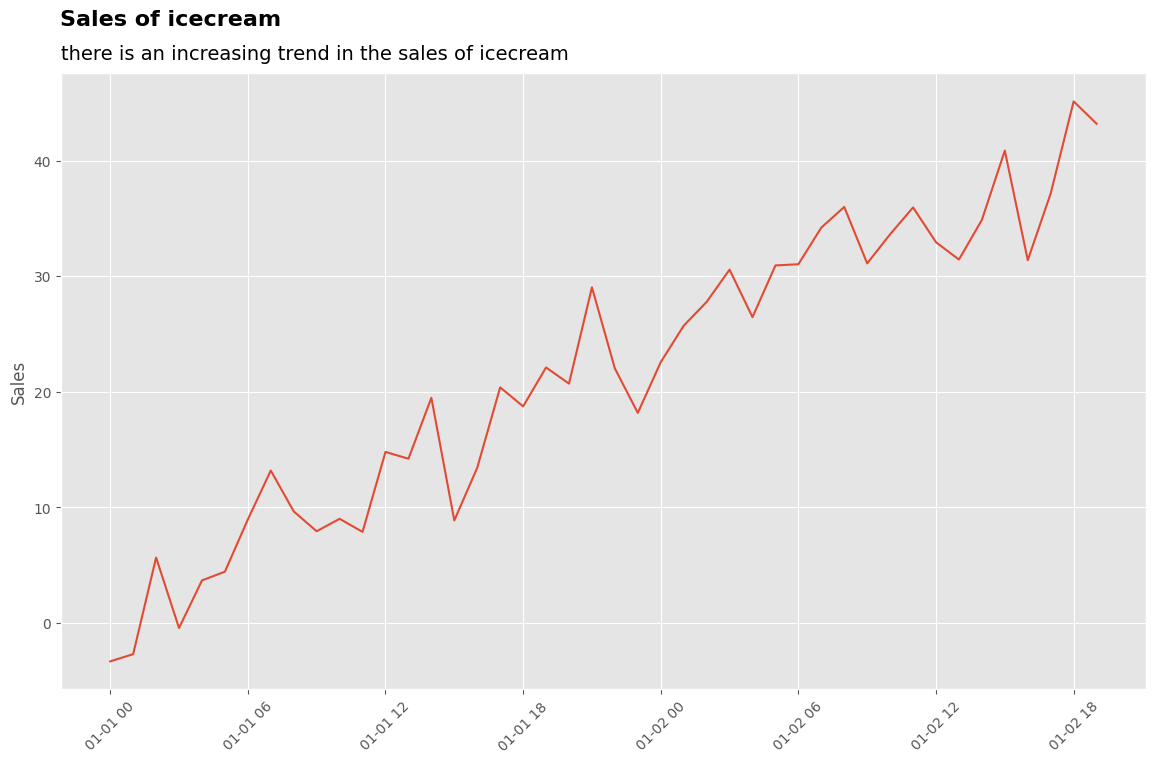

In [41]:
def plot_time_series(
    df_in: pd.DataFrame,
    main_title: Optional[str] = None,
    sub_title: Optional[str] = None,
    minticks: int = 7,
    rule: Optional[str] = None,
    aggfunc: Optional[str] = None,
    ylabel: Optional[str] = None,
) -> None:
    # apply a resample to the data, using the aggfunc to aggregate the data
    if aggfunc and rule:
        df_in = df_in.resample(on="ds", rule=rule).agg({"y": aggfunc}).reset_index()

    # add a warning message that if aggfunc is set but not rule and vice versa that no resampling is done
    if (aggfunc and not rule) or (rule and not aggfunc):
        print("Warning: aggfunc and rule must both be set for resampling to be applied")

    plt.figure(figsize=(14, 8))
    plt.plot(
        df_in["ds"],
        df_in["y"],
    )

    # set the x-axis to show dates
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=minticks))
    plt.xticks(rotation=45)
    plt.ylabel(ylabel)

    # ha,x, and y are set in a hacky way to align the supertitle and subtitle the left
    plt.suptitle(
        main_title,
        fontsize=16,
        fontweight="bold",
        x=0.124,
        y=0.96,
        ha="left",
    )
    plt.title(
        sub_title,
        fontsize=14,
        pad=10,
        loc="left",
    )

    plt.show()


# ---------------------------------------------------------------------------------
nums = 44

# Example usage
df_in = pd.DataFrame(
    {
        "ds": pd.date_range(start="2020-01-01", periods=nums, freq="h"),
        "y": range(nums),
    }
)


# add noise to y
df_in["y"] = df_in["y"] + np.random.normal(0, 3, nums)

plot_time_series(
    df_in,
    # rule="D",
    # aggfunc="mean",
    "Sales of icecream",
    "there is an increasing trend in the sales of icecream",
    ylabel="Sales",
)
# function that takes a timeseries and plot the seasonality of the data


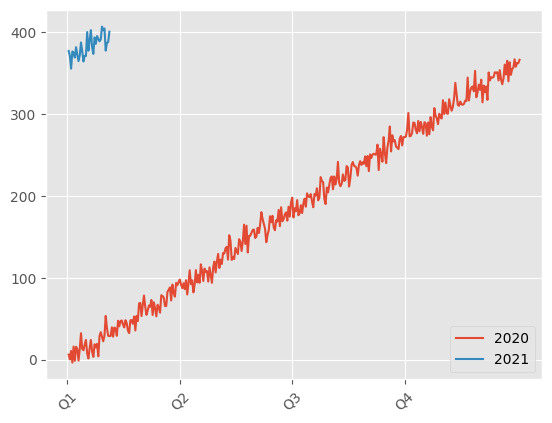

In [ ]:
# function that takes a timeseries and plot the seasonality of the data
# it does so by either plotting all the months  so jan, feb,...,dec
# or by plotting all the quarters so q1, q2,...,q4
# or by plotting all the days so monday, tuesday,...,sunday
# or by plotting 00:00,01:00,...,23:00,24:00
# the input dataframe contains three columns:
# - ds: a daatetime column
# - y: the value of the timeseries
# - unique_id: the unique id of the timeseries
# dont perform any aggregations, this is handeld outside of this function


def plot_seasonality(df_in, seasonality_type="month", minticks=7):
    seasonality_type = seasonality_type.lower()

    if seasonality_type == "quarter":
        for year in df_in["ds"].dt.year.unique():
            df_year = df_in[df_in["ds"].dt.year == year]
            plt.plot(df_year["ds"].dt.day_of_year, df_year["y"], label=year)

        # apply a tick at 01-jan, 01-apr, 01-jul, 01-oct
        # and label them as Q1, Q2, Q3, Q4
        plt.xticks(
            ticks=[0, 91, 182, 273], labels=["Q1", "Q2", "Q3", "Q4"], rotation=45
        )
        plt.xticks(rotation=45)
        plt.legend()
        plt.show()

    elif seasonality_type == "month":
        for year in df_in["ds"].dt.year.unique():
            df_year = df_in[df_in["ds"].dt.year == year]

            # Plot the data for the current year
            plt.plot(df_year["ds"].dt.day_of_year, df_year["y"], label=year)
        # apply all the styling to the plot
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        plt.xticks(rotation=45)
        plt.legend()
        plt.show()

    elif seasonality_type == "week":
        plt.Figure(figsize=(10, 6))
        # create a plot for each week in the dataframe
        for week in df_in["ds"].dt.isocalendar().week.unique():
            df_week = df_in[df_in["ds"].dt.isocalendar().week == week]
            # Plot the data for the current week
            plt.plot(df_week["ds"].dt.dayofweek, df_week["y"], label=week)

        # apply a tick for each day of the week, and apply the name of the day
        # start with monday
        plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
        plt.xticks(rotation=45)
        plt.legend()
        plt.show()

    elif seasonality_type == "day":
        df_in["hour"] = df_in["ds"].dt.hour

        # create a plot for each day in the dataframe
        for day in df_in["ds"].dt.day.unique():
            df_day = df_in[df_in["ds"].dt.day == day]
            plt.plot(df_day["hour"], df_day["y"])

        # apply a format to the x axis as follow 00, 01, 02, etc.
        plt.xticks(range(24), [f"{i:02d}" for i in range(24)])
        plt.xlabel("Hour")
        plt.xticks(rotation=45)
        plt.show()

    else:
        raise ValueError(
            "Invalid seasonality_type. Choose from 'month', 'quarter', 'dayofweek', 'hour'."
        )


nums = 400
df_in = pd.DataFrame(
    {"ds": pd.date_range(start="2020-01-01", periods=nums, freq="d"), "y": range(nums)}
)
df_in["y"] = df_in["y"] + np.random.normal(0, 9, nums)

# Example usage:
plot_seasonality(df_in, seasonality_type="quarter")